# One loop, one exact correction

For a zero-field Ising model on a single cycle, belief propagation gives the tree-like contribution and the loop series contains one nontrivial generalized loop. The exact correction is especially transparent:

$$
Z=Z_{\mathrm{BP}}\left(1+\prod_{e\in C}\tanh J_e\right).
$$

In [1]:
CHAPTER_DIR = "ch09"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Exact and BP partition functions on a cycle

exact 109.19819419626371 BP 108.86565361379236 loop weight 0.0030545959302375634 corrected 109.1981941962637


Saved: figs/ch09_01_single_cycle_correction.pdf


Saved: figs/ch09_01_single_cycle_correction.png


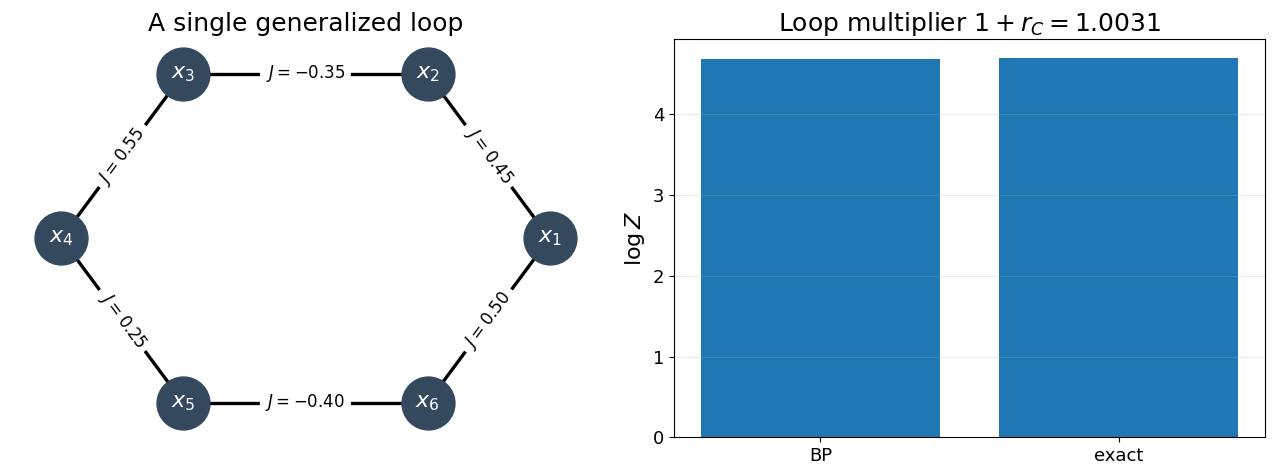

In [2]:
from itertools import product
n=6; Js=np.array([.45,-.35,.55,.25,-.40,.50])
states=np.array(list(product([-1,1],repeat=n)))
weights=np.exp([sum(Js[i]*x[i]*x[(i+1)%n] for i in range(n)) for x in states]); Z=weights.sum()
Zbp=(2**n)*np.prod(np.cosh(Js)); loop=np.prod(np.tanh(Js)); corrected=Zbp*(1+loop)
print('exact',Z,'BP',Zbp,'loop weight',loop,'corrected',corrected); assert np.allclose(Z,corrected)
G=nx.cycle_graph(n); pos=nx.circular_layout(G)
fig,axes=plt.subplots(1,2,figsize=(13,5))
nx.draw_networkx_nodes(G,pos,node_size=1450,node_color=NODE_COLOR,ax=axes[0]); nx.draw_networkx_labels(G,pos,labels={i:rf'$x_{i+1}$' for i in range(n)},font_color='white',font_size=16,ax=axes[0]); nx.draw_networkx_edges(G,pos,width=2.4,ax=axes[0]); nx.draw_networkx_edge_labels(G,pos,edge_labels={(i,(i+1)%n):rf'$J={Js[i]:.2f}$' for i in range(n)},font_size=12,ax=axes[0]); axes[0].set_title('A single generalized loop'); axes[0].axis('off')
axes[1].bar(['BP','exact'],[np.log(Zbp),np.log(Z)]); axes[1].set_ylabel('$\\log Z$'); axes[1].set_title(rf'Loop multiplier $1+r_C={1+loop:.4f}$'); axes[1].grid(axis='y',alpha=.25); fig.tight_layout(); save_figure(fig,'ch09_01_single_cycle_correction'); plt.show()

## Coupling-strength sweep

Saved: figs/ch09_01_loop_strength_sweep.pdf


Saved: figs/ch09_01_loop_strength_sweep.png


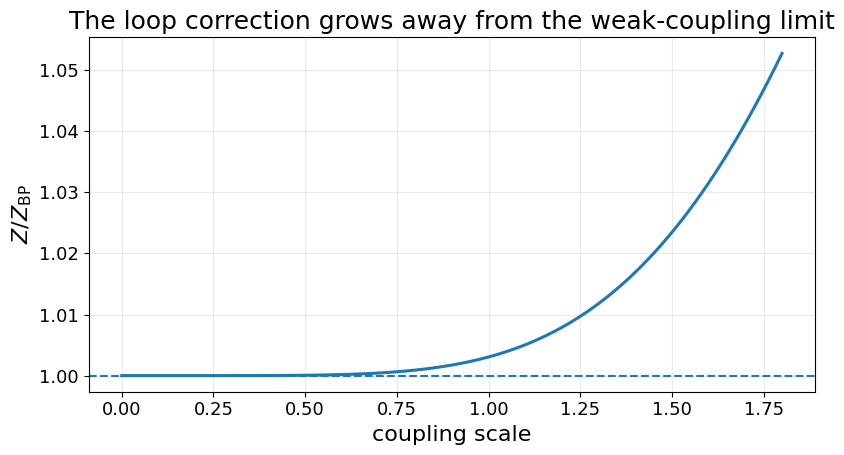

In [3]:
scales=np.linspace(0,1.8,100); ratios=[]
for s in scales: ratios.append(1+np.prod(np.tanh(s*Js)))
fig,ax=plt.subplots(figsize=(8.5,4.8)); ax.plot(scales,ratios,linewidth=2.2); ax.axhline(1,linestyle='--'); ax.set_xlabel('coupling scale'); ax.set_ylabel('$Z/Z_{\\mathrm{BP}}$'); ax.set_title('The loop correction grows away from the weak-coupling limit'); ax.grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch09_01_loop_strength_sweep'); plt.show()

## Exercises

1. Prove the identity by expanding every edge factor as $e^{Jx_ix_j}=\cosh J(1+x_ix_j\tanh J)$.
2. Determine the sign of the correction for an odd number of antiferromagnetic edges.
3. Add local fields and identify why the simple high-temperature formula changes.